=== Decision Tree Report ===
              precision    recall  f1-score   support

          No       0.17      0.91      0.29       269
         Yes       0.99      0.70      0.82      3880

    accuracy                           0.71      4149
   macro avg       0.58      0.80      0.56      4149
weighted avg       0.94      0.71      0.79      4149



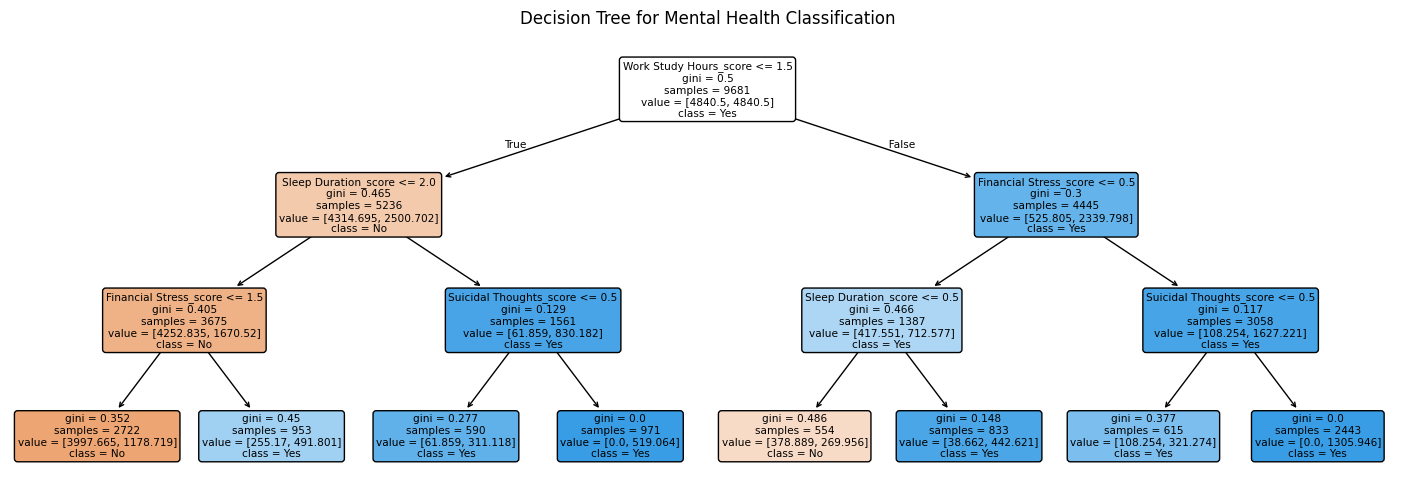

=== Logistic Regression Report ===
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       269
         Yes       1.00      1.00      1.00      3880

    accuracy                           1.00      4149
   macro avg       1.00      1.00      1.00      4149
weighted avg       1.00      1.00      1.00      4149

Logistic Regression Feature Coefficients:
CGPA (categorical)_score: 5.9309
Academic Pressure_score: 5.8032
Study Satisfaction_score: 5.9245
Sleep Duration_score: 6.0164
Dietary Habits_score: 6.0028
Suicidal Thoughts_score: 5.8946
Work Study Hours_score: 6.0206
Financial Stress_score: 6.0216
Family History_score: 5.8684

Decision Tree Feature Importances:
CGPA (categorical)_score: 0.0000
Academic Pressure_score: 0.0000
Study Satisfaction_score: 0.0000
Sleep Duration_score: 0.3900
Dietary Habits_score: 0.0000
Suicidal Thoughts_score: 0.0261
Work Study Hours_score: 0.4013
Financial Stress_score: 0.1827
Family History_score: 0.0000


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load and clean dataset
df = pd.read_excel("preprocessed_depression.csv.xlsx")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Define score mappings
score_maps = {
    'CGPA (categorical)': {"Low": 0, "Average": 1, "High": 2},
    'Academic Pressure': {"Low": 0, "Moderate": 1, "High": 2},
    'Study Satisfaction': {"Low": 0, "Moderate": 1, "High": 2},
    'Sleep Duration': {"Very short": 0, "Short": 1, "7-8 hours": 2, "Long": 3},
    'Dietary Habits': {"Unhealthy": 0, "Moderate": 1, "Healthy": 2},
    'Suicidal Thoughts': {"Yes": 1, "No": 0},
    'Work Study Hours': {"Low": 0, "Moderate": 1, "High": 2},
    'Financial Stress': {"Low": 0, "Moderate": 1, "High": 2},
    'Family History': {"Yes": 1, "No": 0}
}

# Apply scoring
for col, mapping in score_maps.items():
    df[col + "_score"] = df[col].map(mapping)

# Score columns
score_cols = [col + "_score" for col in score_maps]

# Remove rows with any NaN in score columns
df = df.dropna(subset=score_cols)

# Compute total score and classify
df["Total_score"] = df[score_cols].sum(axis=1)
df["Classification"] = df["Total_score"].apply(lambda x: "Yes" if x >= 6 else "No")

# Prepare features and labels
X = df[score_cols]
y = df["Classification"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# --- Decision Tree ---
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight="balanced")
tree_clf.fit(X_train, y_train)
tree_preds = tree_clf.predict(X_test)

print("=== Decision Tree Report ===")
print(classification_report(y_test, tree_preds, target_names=label_encoder.classes_))

plt.figure(figsize=(18, 6))
plot_tree(tree_clf, feature_names=X.columns, class_names=label_encoder.classes_,
          filled=True, rounded=True)
plt.title("Decision Tree for Mental Health Classification")
plt.show()

# --- Logistic Regression ---
logit_clf = LogisticRegression(max_iter=200, class_weight='balanced')
logit_clf.fit(X_train, y_train)
logit_preds = logit_clf.predict(X_test)

print("=== Logistic Regression Report ===")
print(classification_report(y_test, logit_preds, target_names=label_encoder.classes_))

# Coefficients
print("Logistic Regression Feature Coefficients:")
for name, coef in zip(X.columns, logit_clf.coef_[0]):
    print(f"{name}: {coef:.4f}")

# Tree feature importance
print("\nDecision Tree Feature Importances:")
for name, imp in zip(X.columns, tree_clf.feature_importances_):
    print(f"{name}: {imp:.4f}")
